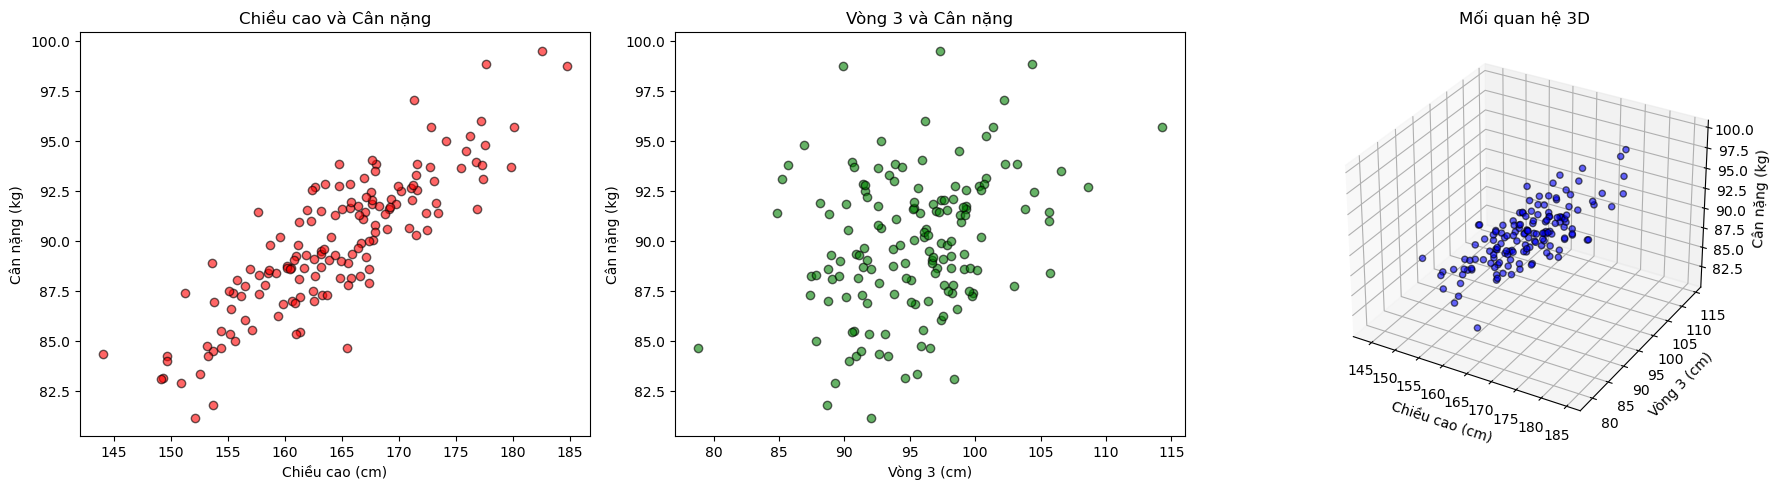

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo dữ liệu giả lập
np.random.seed(42)
num_samples = 150

# Feature: chiều cao (height), vòng 3 (hip)
height = np.random.normal(165, 8, num_samples)  # chiều cao (cm)
hip    = np.random.normal(95, 5, num_samples)   # vòng 3 (cm)
X = np.column_stack((height, hip))

# Trọng số giả lập thực tế
true_weights = np.array([0.4, 0.2])  # giả định hệ số
bias = 5
noise = np.random.normal(0, 1.5, num_samples)
y = X @ true_weights + bias + noise  # cân nặng (kg)

#  Trực quan hóa dữ liệu
fig = plt.figure(figsize=(18,5))

# Biểu đồ 1: Cân nặng vs Chiều cao
plt.subplot(1,3,1)
plt.scatter(height, y, c='red', alpha=0.6, edgecolors='k')
plt.xlabel("Chiều cao (cm)")
plt.ylabel("Cân nặng (kg)")
plt.title("Chiều cao và Cân nặng")

# Biểu đồ 2: Cân nặng vs Vòng 3
plt.subplot(1,3,2)
plt.scatter(hip, y, c='green', alpha=0.6, edgecolors='k')
plt.xlabel("Vòng 3 (cm)")
plt.ylabel("Cân nặng (kg)")
plt.title("Vòng 3 và Cân nặng")

# Biểu đồ 3: 3D - Cân nặng vs Chiều cao & Vòng 3
ax = fig.add_subplot(1,3,3, projection='3d')
ax.scatter(height, hip, y, c='blue', alpha=0.6, edgecolors='k')
ax.set_xlabel("Chiều cao (cm)")
ax.set_ylabel("Vòng 3 (cm)")
ax.set_zlabel("Cân nặng (kg)")
ax.set_title("Mối quan hệ 3D")

plt.tight_layout()
plt.show()

In [2]:
%%time
# 2. Khởi tạo trọng số
w = [0, 0]#np.random.randn(2)
b = 0.0

# 3. Hàm dự đoán và RMSD
def predict(X, w, b):
    return X @ w + b

def rmsd(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# 4. Huấn luyện bằng Gradient Descent
learning_rate = 0.0001
epochs = 1000

for epoch in range(epochs):
    y_pred = predict(X, w, b)
    error = y_pred - y
    rmsd_val = rmsd(y, y_pred)

    # Gradient
    grad_w = (1 / len(y)) * (X.T @ error) / rmsd_val
    grad_b = (1 / len(y)) * np.sum(error) / rmsd_val

    # Cập nhật trọng số
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: RMSD = {rmsd_val:.4f}")

# 5. Kết quả cuối
print("\nFinal weights:", w)
print("Final bias:", b)
print("Final RMSD:", rmsd(y, predict(X, w, b)))

Epoch 0: RMSD = 89.9556
Epoch 100: RMSD = 1.8075
Epoch 200: RMSD = 1.8075
Epoch 300: RMSD = 1.8075
Epoch 400: RMSD = 1.8075
Epoch 500: RMSD = 1.8075
Epoch 600: RMSD = 1.8075
Epoch 700: RMSD = 1.8075
Epoch 800: RMSD = 1.8075
Epoch 900: RMSD = 1.8075

Final weights: [0.41623251 0.23683529]
Final bias: 0.0028369786899018435
Final RMSD: 1.8074930937091103
CPU times: user 22.5 ms, sys: 1.86 ms, total: 24.4 ms
Wall time: 24 ms


In [6]:
%%time
# 2. Khởi tạo trọng số
w = [0, 0]#np.random.randn(2)
b = 0.0

# 3. Hàm dự đoán và RMSD
def predict(X, w, b):
    return X @ w + b

def rmsd(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# 4. Huấn luyện bằng Gradient Descent
batch_size = 10
learning_rate = 0.0001/2
epochs = 1000
n = len(y)

for epoch in range(epochs):
    # shuffle data each epoch
    perm = np.random.permutation(n)
    perm= np.arange(0,n)
    
    X_shuffled = X[perm]
    y_shuffled = y[perm]

    for i in range(0, n, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        y_pred = predict(X_batch, w, b)
        error = y_batch - y_pred
        rmsd_val = rmsd(y_batch, y_pred)

        # avoid division by zero
        eps = 1e-8

        # Gradients (your formulation, batched)
        grad_w = -2 * (X_batch.T @ error) / (len(y_batch) * (rmsd_val + eps))
        grad_b = -2 * np.sum(error) / (len(y_batch) * (rmsd_val + eps))

        # Update
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

    # monitor full-dataset RMSD
    if epoch % 100 == 0:
        full_rmsd = rmsd(y, predict(X, w, b))
        print(f"Epoch {epoch}: RMSD = {full_rmsd:.4f}")


# 5. Kết quả cuối
print("\nFinal weights:", w)
print("Final bias:", b)
print("Final RMSD:", rmsd(y, predict(X, w, b)))

Epoch 0: RMSD = 35.7668
Epoch 100: RMSD = 1.4329
Epoch 200: RMSD = 1.4332
Epoch 300: RMSD = 1.4333
Epoch 400: RMSD = 1.4333
Epoch 500: RMSD = 1.4333
Epoch 600: RMSD = 1.4332
Epoch 700: RMSD = 1.4332
Epoch 800: RMSD = 1.4332
Epoch 900: RMSD = 1.4332

Final weights: [0.41686664 0.22310741]
Final bias: 0.007134177021322726
Final RMSD: 1.433237589722616
CPU times: user 180 ms, sys: 2.97 ms, total: 182 ms
Wall time: 186 ms


In [7]:
#%%time
A = np.concatenate((X, np.ones_like(y,dtype=float).reshape(-1,1)), axis=1)

#b = (A.T @ A)**-1 @ A.T @ y 

b = np.linalg.pinv(A) @ y

print(b)

y_pred = A @ b

print(f'RMSD: {rmsd(y, y_pred)}')

[0.39354946 0.21039172 5.1516445 ]
RMSD: 1.4176822949954304


8

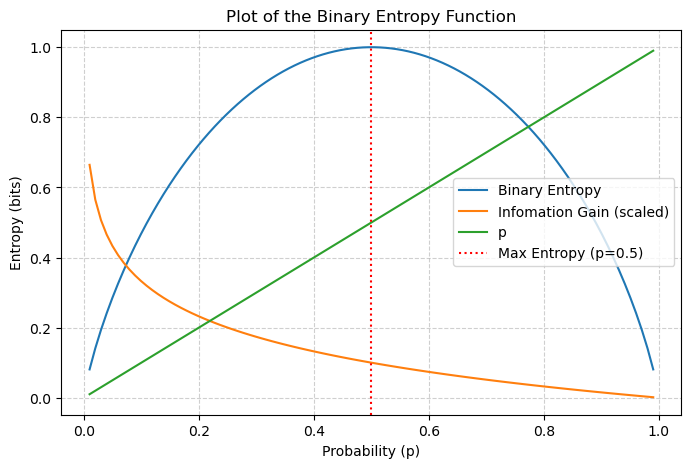

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def binary_entropy(p):
    # Handle cases where p=0 or p=1 to avoid log(0)
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# Probabilities from 0 to 1
p_values = np.linspace(0.01, 0.99, 100)
entropy_values = binary_entropy(p_values)

plt.figure(figsize=(8, 5))
plt.plot(p_values, entropy_values, label='Binary Entropy')
plt.plot(p_values, - np.log2(p_values)/10, label='Infomation Gain (scaled)')
plt.plot(p_values, p_values, label='p')
plt.title('Plot of the Binary Entropy Function')
plt.xlabel('Probability (p)')
plt.ylabel('Entropy (bits)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(0.5, color='r', linestyle=':', label='Max Entropy (p=0.5)')
plt.legend()
plt.show()